# Demo Part 0: Data Understanding

Before we build our machine learning models, we need to understand the raw data. In this notebook, we'll look at the 4 core datasets provided by the AdTech platform.

### 1. The Briefing Data (`briefing.csv`)
This file represents the 'Campaign Level' context. It tells us the budget, the agreed volume, and the dates for each advertising campaign.

In [29]:
import pandas as pd

df_brief = pd.read_csv('../data/briefing.csv')
print(f"Total Campaigns: {len(df_brief)}")

Total Campaigns: 101


In [30]:
df_brief.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 21 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   campaign_id                                        101 non-null    object 
 1   campaign_name                                      101 non-null    object 
 2   Submission Date                                    101 non-null    object 
 3   Description                                        101 non-null    object 
 4   Campaign Objectives                                101 non-null    object 
 5   KPIs                                               101 non-null    object 
 6   Placement(s)                                       101 non-null    object 
 7   StartDate                                          101 non-null    object 
 8   EndDate                                            101 non-null    object 
 9   Serving Lo

In [31]:
df_brief[['campaign_id', 'Campaign Objectives', 'Buy Rate (CPE)', 'Gross Cost/Budget', 'Volume Agreed', 'StartDate', 'EndDate']].head()

,campaign_id,Campaign Objectives,Buy Rate (CPE),Gross Cost/Budget,Volume Agreed,StartDate,EndDate
0,shg01yl,Brand Awareness,0.4,212471.6,531179.0,01/03/2020,30/11/2020
1,rom3zao,Brand Awareness,0.4,212471.6,531179.0,01/03/2020,30/11/2020
2,lvkar9i,Brand Awareness,0.4,212471.6,531179.0,01/03/2020,30/11/2020
3,8muucqy,Brand Awareness,0.4,212471.6,531179.0,01/03/2020,30/11/2020
4,xygdmea,Brand Awareness,0.4,212471.6,531179.0,01/03/2020,30/11/2020


### 2. The Inventory Logs (`campaigns_inventory_updated.csv`)
This is the massive 100MB+ event log. Every time a user sees an ad (impression) or clicks it, a row is generated here.

In [26]:
df_inv = pd.read_csv('../data/campaigns_inventory_updated.csv', nrows=1000)
print("Sample of raw events:")
df_inv[['game_key', 'type', 'device_type', 'platform_os', 'geo_country']].head()

Sample of raw events:


,game_key,type,device_type,platform_os,geo_country
0,adunit-facebook-conversational-commerce-phase-2-thailand-coffeehouse-mob-v2/48e47efe77cf8ba829f3,impression,Mobile,6,Thailand
1,adunit-facebook-conversational-commerce-phase-2-thailand-coffeehouse-mob-v2/48e47efe77cf8ba829f3,impression,Mobile,6,Thailand
2,adunit-facebook-conversational-commerce-phase-2-thailand-baanraya-mob-v2/a8656a5a1477a8cac5f0,impression,Mobile,6,Thailand
3,adunit-facebook-conversational-commerce-phase-2-thailand-coffeehouse-mob-v2/48e47efe77cf8ba829f3,impression,Mobile,6,Thailand
4,adunit-facebook-conversational-commerce-phase-2-thailand-coffeehouse-mob-v2/48e47efe77cf8ba829f3,impression,Mobile,6,Thailand


### 3. The Global Design Metadata (`global_design_data.json`)
This JSON file is provided by the creative design agency. It contains AI-extracted labels, dominant colors, and text embedded in the ad images.

In [33]:
import json

with open('../data/global_design_data.json', 'r') as f:
    design = json.load(f)

sample_key = list(design.keys())[0]
sample_request_id = list(design[sample_key].keys())[0]

print(f"Game Key (MD5): {sample_key}")
print(f"Request ID: {sample_request_id}\n")
print("--- Raw JSON Payload ---")
print(json.dumps(design[sample_key][sample_request_id], indent=2))

Game Key (MD5): f910338e60315f02812b05e932068f47
Request ID: 1028d033d74dd2e24f67

--- Raw JSON Payload ---
{
  "labels": {
    "engagement": [
      "Asphalt",
      "Tarmac",
      "Road",
      "Runway"
    ],
    "click_through": [
      "Asphalt",
      "Tarmac",
      "Road",
      "Runway"
    ]
  },
  "text": {
    "engagement": [
      "Amazing Hong Kong",
      "air",
      "deals!",
      "Swipe Up",
      "BEST",
      "OF ALL",
      "IT'S IN",
      "HONG",
      "KONG"
    ],
    "click_through": [
      "Amazing Hong Kong",
      "air",
      "deals!",
      "Swipe Up",
      "BEST",
      "OF ALL",
      "IT'S IN",
      "HONG",
      "KONG"
    ]
  },
  "colors": {
    "engagement": {
      "1": {
        "red": 153,
        "green": 154,
        "blue": 167,
        "proportion": 0.21955128205128205,
        "saturation": 0.07368421052631581,
        "luminosity": 0.6274509803921569
      },
      "2": {
        "red": 32,
        "green": 43,
        "blue": 66,
   

### Decoding the Global Design Metadata

The JSON payload above represents the metadata for a single ad creative. In real-world AdTech, creative agencies use AI to extract metadata from images before sending them to the data team. 

Here is how we use this unstructured JSON to build Machine Learning features:

**1. `labels` (AI Vision Tags)**
*   **What it is:** Objects or concepts identified in the image by an AI vision model.
*   **Example:** `["Asphalt", "Tarmac", "Road", "Runway"]`
*   **Why we care:** This tells our model the *context* of the image. For example, do ads featuring cars perform better than ads featuring coffee?

**2. `text` (Optical Character Recognition - OCR)**
*   **What it is:** The actual words printed on the ad image.
*   **Example:** `["Amazing Hong Kong", "air", "deals!", "Swipe Up"]`
*   **Why we care:** This allows us to count the number of words on the screen. Too much text might overwhelm users and lower the Click-Through Rate.

**3. `colors` (Palette Analysis)**
*   **What it is:** A mathematical breakdown of the top dominant colors in the image.
*   **Example:** RGB values (`"red": 153, "green": 154, "blue": 167`) and their `"proportion"` (e.g., this grayish-blue makes up 21% of the image).
*   **Why we care:** We use these raw values in our feature engineering pipeline to calculate the overall brightness and colorfulness of the ad.

**4. `videos_data` & `direction` (Formatting)**
*   **What it is:** Structural metadata about the ad unit format.
*   **Example:** `has_video: 0` means it's a static image. `direction: "up"` indicates it might be a "Swipe Up" mobile story format.
*   **Why we care:** Video ads typically have vastly different engagement profiles than static images, making `has_video` a crucial feature for the model.

### 4. The Creative Assets (`Creative Assets_/*.png`)
Finally, these are the actual physical images that are shown to the users. Our goal is to extract features directly from these pixels!

Total physical images: 144


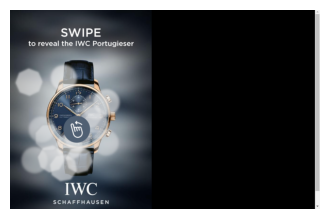

In [28]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_dir = '../data/Creative Assets_'
images = os.listdir(image_dir)
print(f"Total physical images: {len(images)}")

# Show one
sample_img = Image.open(os.path.join(image_dir, images[0]))
plt.figure(figsize=(4,6))
plt.imshow(sample_img)
plt.axis('off')
plt.show()